# 02 — Custom CNN Model

## Driver Drowsiness Detection

This notebook builds and evaluates a **Custom Convolutional Neural Network (CNN)** using the preprocessed dataset prepared in Notebook 1.

### Objectives

- Load the same train/validation/test split created in Notebook 1
- Build a CNN from scratch
- Train the model using Adam optimization
- Monitor training and validation performance
- Evaluate the model on unseen test data
- Generate accuracy/loss plots
- Generate a confusion matrix
- Generate a classification report
- Save the trained model for later comparison

### Four Classes

1. `Closed`
2. `Open`
3. `no_yawn`
4. `yawn`

## 1. Import Libraries

In [1]:
import os
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version: 2.21.0
Available GPUs: []


## 2. Configuration and Paths

This notebook reuses the exact split metadata generated by `01_dataset_exploration.ipynb`.

In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

CLASS_NAMES = ["Closed", "Open", "no_yawn", "yawn"]

OUTPUT_DIR = Path("../outputs")
if not OUTPUT_DIR.exists():
    OUTPUT_DIR = Path("outputs")

MODEL_DIR = Path("../models")
if not MODEL_DIR.exists():
    MODEL_DIR = Path("models")

MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR.resolve())
print("Model directory:", MODEL_DIR.resolve())

Output directory: D:\driver-drowsiness-detection\outputs
Model directory: D:\driver-drowsiness-detection\models


In [36]:
from tensorflow import keras

model = keras.models.load_model("../models/custom_cnn.keras")

print("Custom CNN model loaded successfully!")

Custom CNN model loaded successfully!


## 3. Load Train / Validation / Test Split Metadata

In [3]:
train_csv = OUTPUT_DIR / "train_split.csv"
val_csv = OUTPUT_DIR / "validation_split.csv"
test_csv = OUTPUT_DIR / "test_split.csv"

if not train_csv.exists():
    raise FileNotFoundError(
        "Split files not found. Run 01_dataset_exploration.ipynb first."
    )

train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)

print("Training images  :", len(train_df))
print("Validation images:", len(val_df))
print("Test images      :", len(test_df))

Training images  : 2030
Validation images: 435
Test images      : 435


## 4. Create TensorFlow Dataset Pipeline

In [4]:
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def make_dataset(dataframe, shuffle=False):
    paths = dataframe["filepath"].values
    labels = dataframe["label"].values.astype(np.int32)

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df, shuffle=False)
test_ds = make_dataset(test_df, shuffle=False)

print(train_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


## 5. Data Augmentation

Augmentation is applied inside the model so that it is active during training but inactive during validation and testing.

In [5]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomBrightness(0.15),
], name="data_augmentation")

data_augmentation

<Sequential name=data_augmentation, built=False>

## 6. Build the Custom CNN

The model contains multiple convolutional blocks followed by global average pooling and dense classification layers.

Architecture:

`Input → Augmentation → Conv → Pool → Conv → Pool → Conv → Pool → Conv → Global Average Pooling → Dense → Output`

In [6]:
def build_custom_cnn(num_classes=4):
    inputs = keras.Input(
        shape=(*IMG_SIZE, 3),
        name="image_input"
    )

    x = data_augmentation(inputs)

    x = layers.Conv2D(
        32, 3, padding="same", activation="relu"
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(
        64, 3, padding="same", activation="relu"
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(
        128, 3, padding="same", activation="relu"
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(
        256, 3, padding="same", activation="relu"
    )(x)
    x = layers.BatchNormalization()(x)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dropout(0.40)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.30)(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        name="class_output"
    )(x)

    return keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="Custom_CNN"
    )

custom_cnn = build_custom_cnn()
custom_cnn.summary()

Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_output (Dense)            │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,748 (1.62 MB)

 Trainable params: 422,788 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

## 7. Compile the Model

We use:

- **Optimizer:** Adam
- **Learning rate:** 0.001
- **Loss:** Sparse categorical cross-entropy
- **Metric:** Accuracy

In [7]:
custom_cnn.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


## 8. Configure Training Callbacks

In [8]:
custom_model_path = MODEL_DIR / "custom_cnn.keras"

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(custom_model_path),
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

print("Best model will be saved to:")
print(custom_model_path.resolve())

Best model will be saved to:
D:\driver-drowsiness-detection\models\custom_cnn.keras


## 9. Train the Custom CNN

The model is trained for a maximum of 20 epochs. Early stopping can end training earlier if validation performance stops improving.

In [9]:
start_time = time.time()

history = custom_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

training_time_seconds = time.time() - start_time
training_time_minutes = training_time_seconds / 60

print(
    f"Training completed in "
    f"{training_time_minutes:.2f} minutes."
)

Epoch 1/20


d:\driver-drowsiness-detection\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2498 - loss: 1.5646
Epoch 1: val_accuracy improved from None to 0.25057, saving model to ..\models\custom_cnn.keras

Epoch 1: finished saving model to ..\models\custom_cnn.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.2498 - loss: 1.5646 - val_accuracy: 0.2506 - val_loss: 1.3982 - learning_rate: 0.0010
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2320 - loss: 1.4756
Epoch 2: val_accuracy did not improve from 0.25057
64/64 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.2320 - loss: 1.4756 - val_accuracy: 0.2506 - val_loss: 1.4121 - learning_rate: 0.0010
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2621 - loss: 1.4279
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.

Epoch 3: val_accuracy did not improve from 0.25057
64/64 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.2621 - loss: 1.4279 - val_accuracy: 0.2506 - val_loss: 1.4177 - learning_rate: 0.0010
Epoch

## 10. Training History

In [10]:
history_df = pd.DataFrame(history.history)
display(history_df)

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.249754,1.564619,0.250575,1.398179,0.001000
1,0.232020,1.475585,0.250575,1.412061,0.001000
2,0.262069,1.427893,0.250575,1.417665,0.001000
3,0.253695,1.421158,0.250575,1.395540,0.000300
4,0.258621,1.415032,0.250575,1.374837,0.000300
5,0.253202,1.403348,0.250575,1.378046,0.000300
6,0.238424,1.410083,0.259770,1.368688,0.000300
7,0.252217,1.402048,0.275862,1.383094,0.000300
8,0.249754,1.403369,0.367816,1.347033,0.000300
9,0.234975,1.400320,0.494253,1.330864,0.000300


## 11. Plot Training and Validation Accuracy

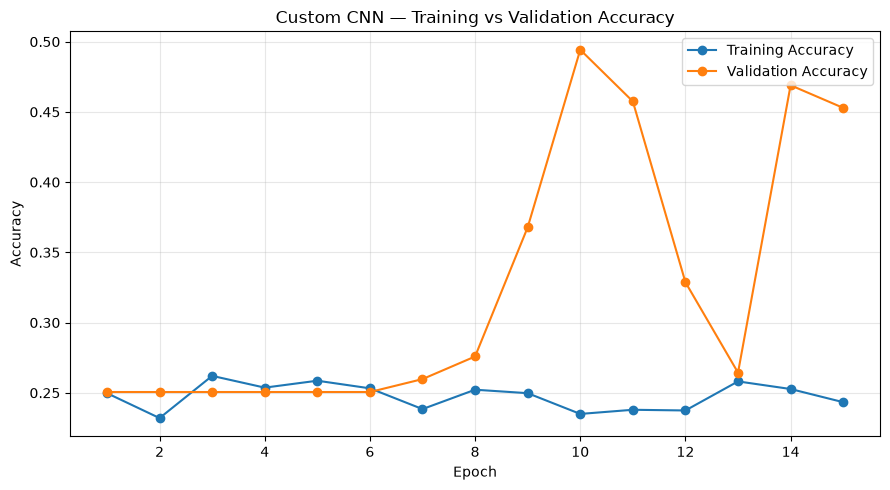

In [11]:
epochs = range(1, len(history.history["accuracy"]) + 1)

plt.figure(figsize=(9, 5))
plt.plot(
    epochs,
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)
plt.plot(
    epochs,
    history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("Custom CNN — Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Plot Training and Validation Loss

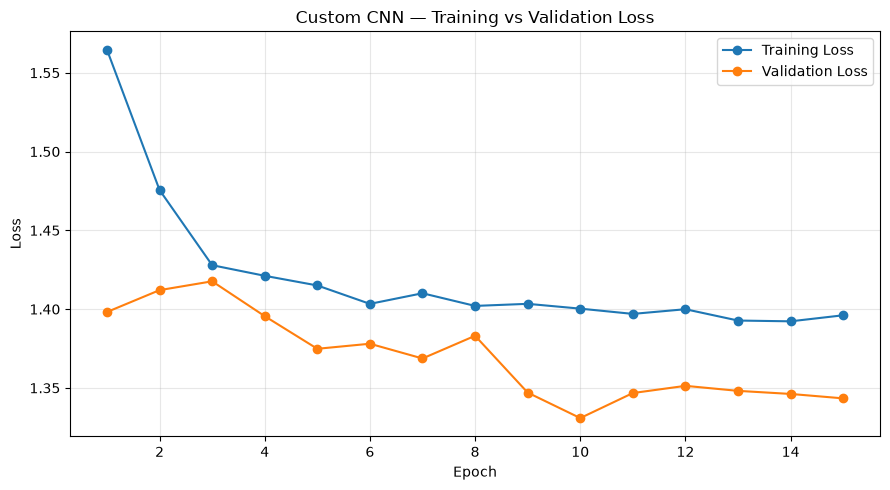

In [12]:
plt.figure(figsize=(9, 5))
plt.plot(
    epochs,
    history.history["loss"],
    marker="o",
    label="Training Loss"
)
plt.plot(
    epochs,
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("Custom CNN — Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Evaluate the Model on the Test Set

In [13]:
test_loss, test_accuracy = custom_cnn.evaluate(
    test_ds,
    verbose=1
)

print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 515ms/step - accuracy: 0.4874 - loss: 1.3312
Test Loss    : 1.3312
Test Accuracy: 0.4874


## 14. Generate Test Predictions

In [14]:
test_probabilities = custom_cnn.predict(
    test_ds,
    verbose=1
)

test_predictions = np.argmax(
    test_probabilities,
    axis=1
)

y_true = test_df["label"].values

print("Number of predictions:", len(test_predictions))
print("Number of true labels:", len(y_true))

14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 392ms/step
Number of predictions: 435
Number of true labels: 435


## 15. Classification Report

In [15]:
report = classification_report(
    y_true,
    test_predictions,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

      Closed     0.4818    0.9725    0.6444       109
        Open     0.0000    0.0000    0.0000       109
     no_yawn     0.4930    0.9722    0.6542       108
        yawn     0.5000    0.0092    0.0180       109

    accuracy                         0.4874       435
   macro avg     0.3687    0.4885    0.3292       435
weighted avg     0.3684    0.4874    0.3284       435



## 16. Calculate Overall Metrics

In [16]:
custom_accuracy = accuracy_score(
    y_true,
    test_predictions
)

custom_precision = precision_score(
    y_true,
    test_predictions,
    average="weighted",
    zero_division=0
)

custom_recall = recall_score(
    y_true,
    test_predictions,
    average="weighted",
    zero_division=0
)

custom_f1 = f1_score(
    y_true,
    test_predictions,
    average="weighted",
    zero_division=0
)

custom_metrics = {
    "Model": "Custom CNN",
    "Accuracy": custom_accuracy,
    "Precision": custom_precision,
    "Recall": custom_recall,
    "F1 Score": custom_f1,
    "Training Time (minutes)": training_time_minutes
}

display(
    pd.DataFrame([custom_metrics])
)

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (minutes)
0,Custom CNN,0.487356,0.368408,0.487356,0.328403,42.024781


## 17. Confusion Matrix

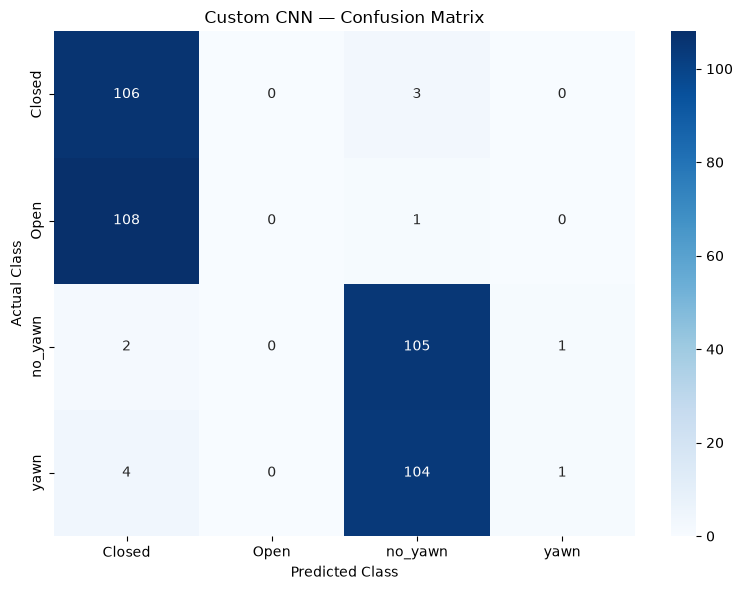

In [17]:
cm = confusion_matrix(
    y_true,
    test_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title("Custom CNN — Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

## 18. Per-Class Performance

In [18]:
class_report_dict = classification_report(
    y_true,
    test_predictions,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

per_class_df = pd.DataFrame(class_report_dict).T

display(
    per_class_df.loc[
        CLASS_NAMES,
        ["precision", "recall", "f1-score", "support"]
    ]
)

,precision,recall,f1-score,support
Closed,0.481818,0.972477,0.644377,109.0
Open,0.000000,0.000000,0.000000,109.0
no_yawn,0.492958,0.972222,0.654206,108.0
yawn,0.500000,0.009174,0.018018,109.0


In [20]:
from PIL import Image

## 19. Display Sample Predictions

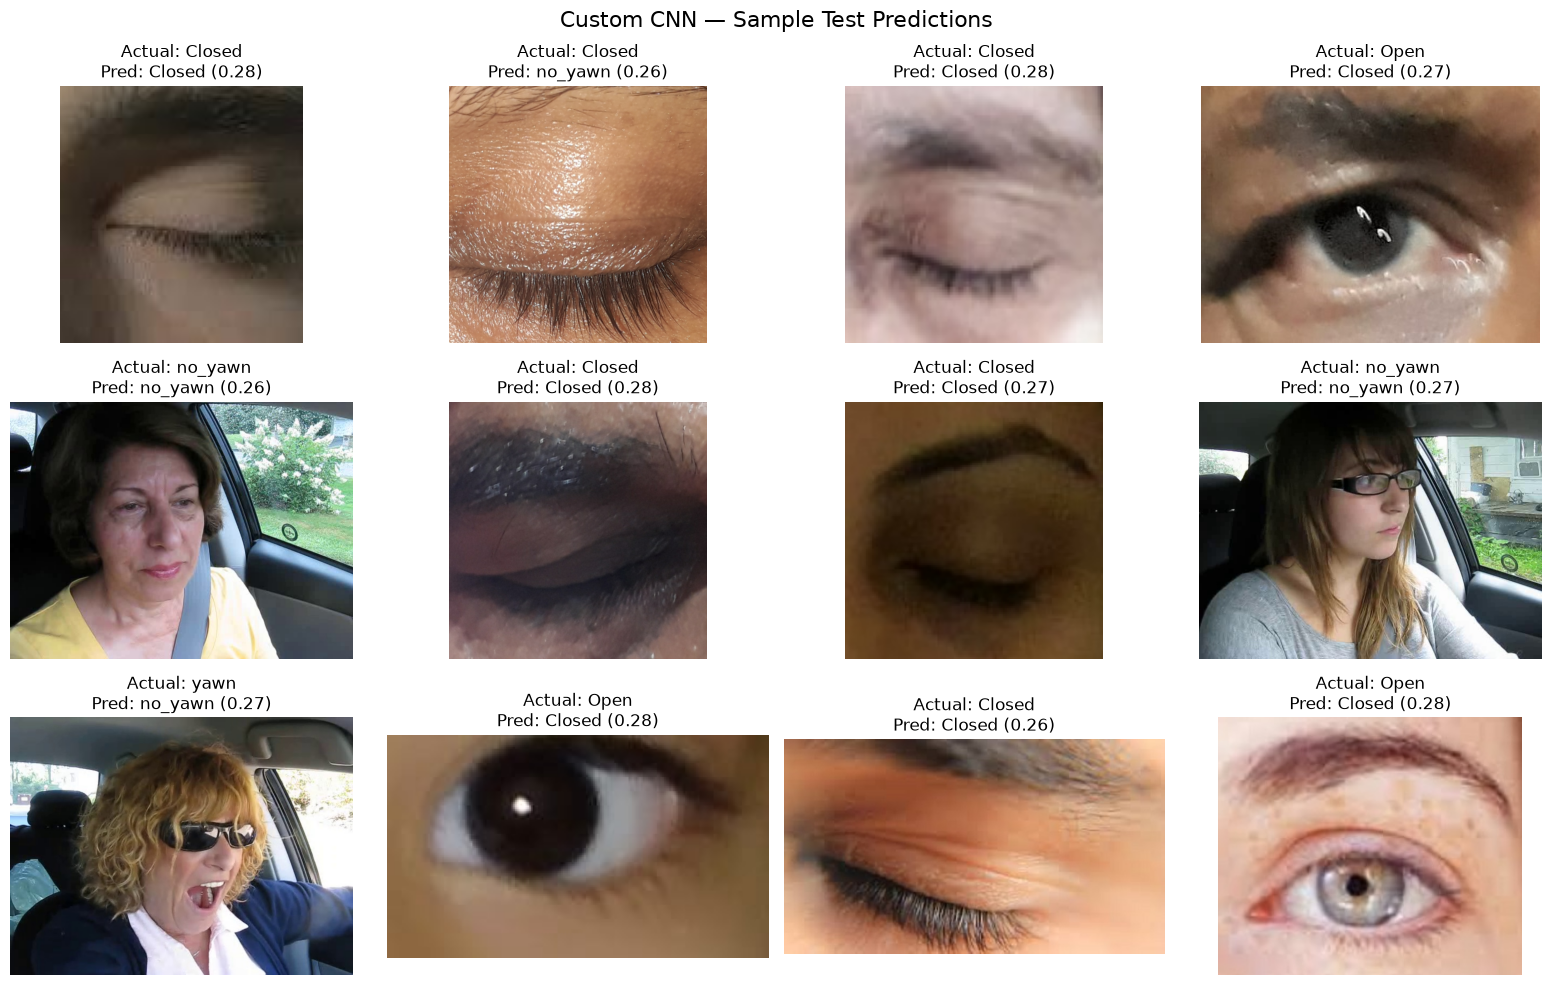

In [21]:
sample_n = min(12, len(test_df))

sample_indices = np.random.choice(
    len(test_df),
    size=sample_n,
    replace=False
)

plt.figure(figsize=(16, 10))

for plot_index, data_index in enumerate(sample_indices):
    file_path = test_df.iloc[data_index]["filepath"]

    image = Image.open(file_path).convert("RGB")

    actual_label = CLASS_NAMES[
        int(y_true[data_index])
    ]

    predicted_label = CLASS_NAMES[
        int(test_predictions[data_index])
    ]

    confidence = float(
        test_probabilities[data_index].max()
    )

    ax = plt.subplot(3, 4, plot_index + 1)
    ax.imshow(image)

    ax.set_title(
        f"Actual: {actual_label}\n"
        f"Pred: {predicted_label} ({confidence:.2f})"
    )

    ax.axis("off")

plt.suptitle(
    "Custom CNN — Sample Test Predictions",
    fontsize=16
)

plt.tight_layout()
plt.show()

## 20. Inspect Misclassified Images

Total misclassified images: 223


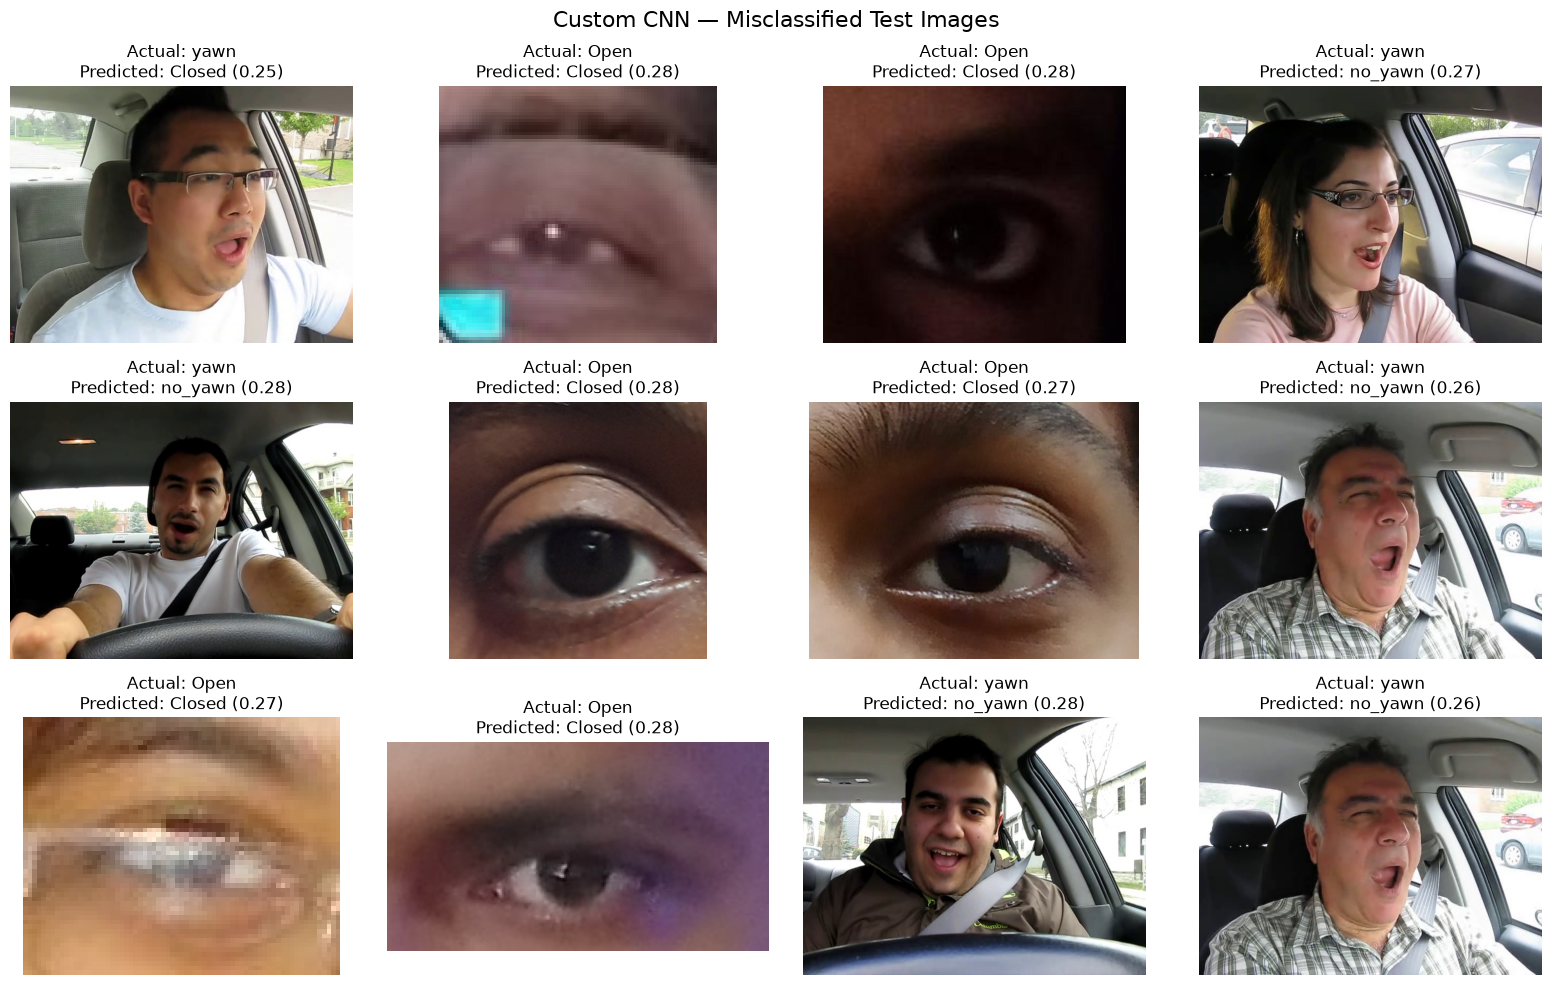

In [22]:
wrong_indices = np.where(
    y_true != test_predictions
)[0]

print("Total misclassified images:", len(wrong_indices))

show_n = min(12, len(wrong_indices))

if show_n > 0:
    plt.figure(figsize=(16, 10))

    for plot_index, data_index in enumerate(
        wrong_indices[:show_n]
    ):
        file_path = test_df.iloc[data_index]["filepath"]
        image = Image.open(file_path).convert("RGB")

        actual_label = CLASS_NAMES[
            int(y_true[data_index])
        ]

        predicted_label = CLASS_NAMES[
            int(test_predictions[data_index])
        ]

        confidence = float(
            test_probabilities[data_index].max()
        )

        ax = plt.subplot(3, 4, plot_index + 1)
        ax.imshow(image)

        ax.set_title(
            f"Actual: {actual_label}\n"
            f"Predicted: {predicted_label} ({confidence:.2f})"
        )

        ax.axis("off")

    plt.suptitle(
        "Custom CNN — Misclassified Test Images",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()
else:
    print("No misclassified test images.")

## 21. Save the Final Custom CNN Model

In [23]:
# The callback has already saved the best validation model.
# Save the current model as an additional final copy.

final_custom_path = MODEL_DIR / "custom_cnn_final.keras"

custom_cnn.save(final_custom_path)

print("Best checkpoint:", custom_model_path.resolve())
print("Final model    :", final_custom_path.resolve())

Best checkpoint: D:\driver-drowsiness-detection\models\custom_cnn.keras
Final model    : D:\driver-drowsiness-detection\models\custom_cnn_final.keras


## 22. Save Custom CNN Metrics

In [24]:
metrics_path = OUTPUT_DIR / "custom_cnn_metrics.csv"

pd.DataFrame([custom_metrics]).to_csv(
    metrics_path,
    index=False
)

print("Metrics saved to:", metrics_path.resolve())

Metrics saved to: D:\driver-drowsiness-detection\outputs\custom_cnn_metrics.csv


# 23. Conclusion

The Custom CNN has now been trained and evaluated on the unseen test set.

Record the actual results produced by this notebook for:

- Test accuracy
- Precision
- Recall
- F1-score
- Training time
- Per-class performance
- Common misclassification patterns

These results will later be compared with the **MobileNetV2 transfer-learning model** in Notebook 4.